<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/project_sam/project_sam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [1]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"samcarver","key":"7af74a420222abec339ce7b22c68c27e"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!pip install kagglehub

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 741M/741M [00:03<00:00, 197MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4


In [55]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
#from tensorflow.keras import layers, Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import os

print("Root:", path)
print("Level 1:", os.listdir(path))

for item in os.listdir(path):
    sub = os.path.join(path, item)
    if os.path.isdir(sub):
        print(f"\n{sub}:")
        print(os.listdir(sub)[:10])

Root: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4
Level 1: ['with_profile_1', 'with_profile', 'with_profile_Jenny_1', 'dataset_split', 'data']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_1:
['with_profile_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile:
['with_profile']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_Jenny_1:
['with_profile_Jenny_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/dataset_split:
['train', 'test']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/data:
['data']


In [10]:
dataset_path = os.path.join(path, "data", "data")
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# collect full dataset and labels
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    for f in os.listdir(label_path):
        if f.lower().endswith(valid_ext):
            full_path = os.path.join(label_path, f)
            image_paths.append(full_path)
            labels.append(label)

# Train/Test split -> random 42 to reporduce it
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# make function to copy paths into folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        shutil.copy2(src_path, dest_path)

# copy into class folders
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

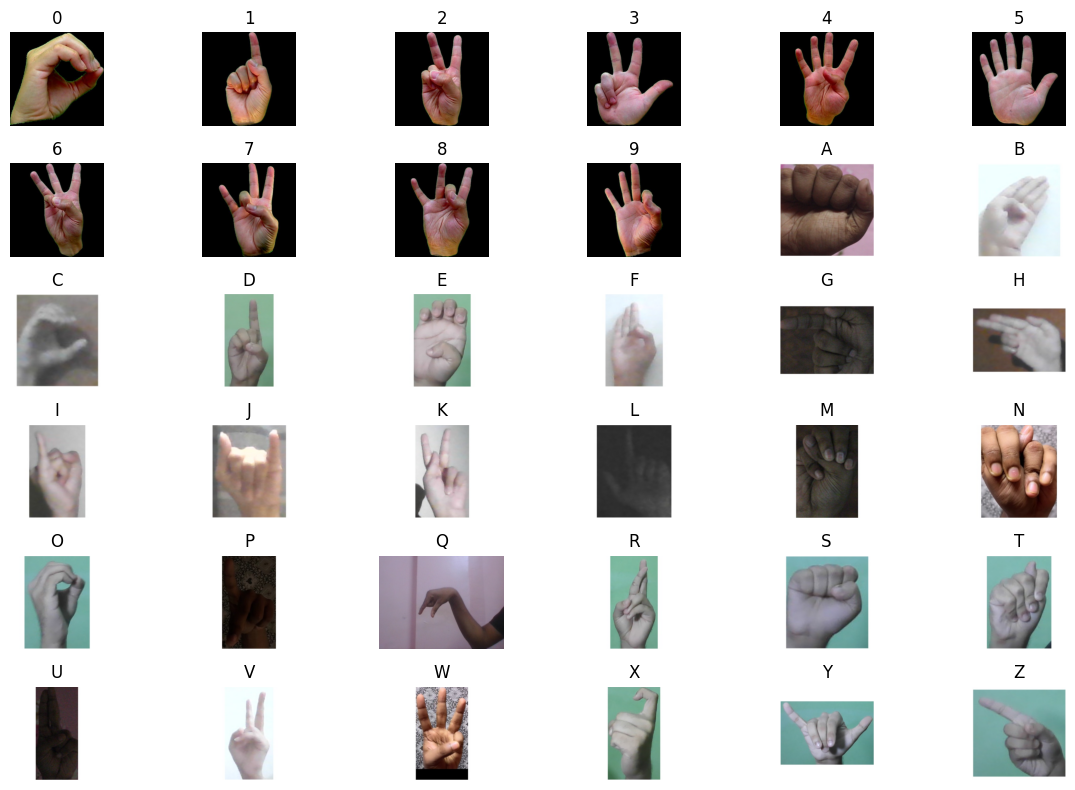

In [58]:
train_path = path + "/dataset_split/train"  # train path
labels = sorted(os.listdir(train_path))      # labels from folder names

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    # move images to class folder
    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    # pick one random image per class
    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

load the base of MobileNetV2

In [59]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

Find what layers we should exit from:

In [60]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer_1
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

The expabded relu is where we want to make the early exits, before it is projected

In [61]:
#Exit1 = BaseModel.get_layer("block_3_expand_relu").output
#Exit2 = BaseModel.get_layer("block_12_expand_relu").output

#def ExitHead(x, NumClasses):
#  x = layers.GlobalAveragePooling2D()(x)
#  x = layers.Dense(128, activation='relu')(x)
#  return layers.Dense(NumClasses, activation='softmax')(x)

#Exit1Output = ExitHead(Exit1, 10)
#Exit2Output = ExitHead(Exit2, 10)


#x = BaseModel.output
#x = layers.GlobalAveragePooling2D()(x)
#FinalOutput = layers.Dense(10, activation='softmax')(x)

#NewModel = Model(inputs=BaseModel.input,
#                 outputs=[Exit1Output, Exit2Output, FinalOutput])

In [62]:
### GET TRAINING DATA ###


num_classes = len(labels)
print(f"{num_classes} classes for training.")

# redefine train_ds and test_ds using
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)


train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

for images, labels_one_hot in test_ds.take(1):
    break

36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.


In [68]:
### TRAIN THE MODEL ###


# Redefine the ExitHead function and the model with the correct number of classes
Exit1 = BaseModel.get_layer("block_7_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = tf.keras.layers.Conv2D(128, (1,1), padding='same', activation='relu')(x)
  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.GlobalAveragePooling2D()(x)
  x = tf.keras.layers.Dense(128, activation='relu')(x)
  x = tf.keras.layers.Dropout(0.5)(x)
  return tf.keras.layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = tf.keras.layers.Conv2D(128, (1,1), padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
FinalOutput = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

NewModel = tf.keras.Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


# Compile the model
NewModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=['categorical_crossentropy'] * 3,
    loss_weights = [0.5, 0.5, 1.0],
    metrics=['accuracy'] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# Fit the model
print("\nStarting model training...")
NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 1,
)


Starting model training...
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 231s 157ms/step - dense_30_accuracy: 0.6870 - dense_30_loss: 1.0042 - dense_32_accuracy: 0.9156 - dense_32_loss: 0.3450 - dense_34_accuracy: 0.9542 - dense_34_loss: 0.2088 - loss: 0.8834 - val_dense_30_accuracy: 0.2947 - val_dense_30_loss: 4.4748 - val_dense_32_accuracy: 0.5993 - val_dense_32_loss: 2.2701 - val_dense_34_accuracy: 0.4003 - val_dense_34_loss: 3.6425 - val_loss: 7.0070


In [75]:
NewModel.save("/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model.h5")

In [76]:
#run if you want to load model
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model.h5")

In [48]:
#run if you want to use newely trained model
LoadedModel = NewModel

In [78]:
### TENSORFLOW IS STUPID ###

!pip install -q tensorflow-model-optimization
import tensorflow_model_optimization as tfmot

In [80]:
### PRUNING STUFF ###


prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude
## Print weights before and after

# Define model for pruning. The 0.5 is the target sparsity (50%)
pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=1000
    )
}

#def apply_pruning(layer):
#    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
#        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
#    return layer##

#pruned_model = tf.keras.models.clone_model(
#    LoadedModel,
#    clone_function=apply_pruning
#)

pruned_model = prune_low_magnitude(LoadedModel, **pruning_params)

# copy weights over
pruned_model.set_weights(LoadedModel.get_weights())

# `prune_low_magnitude` requires a recompile.
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#pruned_model.summary()


### FINE TUNING ###
callbacks = [
  tfmot.sparsity.keras.UpdatePruningStep(),
]

pruned_model.fit(train_images, train_labels, epochs=2, validation_split=0.1,
                  callbacks=callbacks)

### STRIP ###
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
stripped_pruned_model.save('stripped_pruned_model.h5')

ValueError: `prune_low_magnitude` can only prune an object of the following types: keras.models.Sequential, keras functional model, keras.layers.Layer, list of keras.layers.Layer. You passed an object of type: Functional.

In [ ]:
### VALIDATE PRUNING ###
def print_model_weights_sparsity(model):

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Wrapper):
            weights = layer.trainable_weights
        else:
            weights = layer.weights
        for weight in weights:
            if "kernel" not in weight.name or "centroid" in weight.name:
                continue
            weight_size = weight.numpy().size
            zero_num = np.count_nonzero(weight == 0)
            print(
                f"{weight.name}: {zero_num/weight_size:.2%} sparsity ",
                f"({zero_num}/{weight_size})",
            )
print_model_weights_sparsity(stripped_pruned_model)

In [ ]:
### ONLY RUN IF YOU WANT TO EVALUATE PRUNED MODEL ###
LoadedModel = stripped_pruned_model

In [19]:
results = LoadedModel.evaluate(test_ds, verbose=0)
metric_names = LoadedModel.metrics_names

# zip ensures matching length
df = pd.DataFrame(list(zip(metric_names, results)),
                  columns=["Metric", "Value"])

print(df.to_string(index=False))

         Metric    Value
           loss 2.013220
compile_metrics 2.814903
   dense_6_loss 0.243833
   dense_8_loss 0.481042
  dense_10_loss 0.896653


In [20]:
### USE THE TRAINED MODEL TO MAKE PREDICTIONS FOR VALIDATION ###

predictions = LoadedModel.predict(images)
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
exit_names = ["Exit 1 (early exit)", "Exit 2 (intermediate exit)", "Final Output"]

for i, pred in enumerate(predictions):
    y_pred = np.argmax(pred, axis=1)
    accuracy = np.mean(y_pred == true_labels)
    print(f"Overall accuracy for {exit_names[i]}: {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Overall accuracy for Exit 1 (early exit): 31.25%
Overall accuracy for Exit 2 (intermediate exit): 87.50%
Overall accuracy for Final Output: 78.12%


In [21]:
### CODE FOR MEASURING MODEL SIZE IN MB ###
import tempfile

def get_model_size(model):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".keras", delete=False)
    model.save(tmp_file.name)

    size = os.path.getsize(tmp_file.name)
    return size / (1024**2)  # MB


FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])


print("Full model size (MB):", get_model_size(NewModel))
print("Final model size (MB):", get_model_size(FinalModel))

Full model size (MB): 29.98770809173584
Final model size (MB): 9.88613510131836


In [24]:
### CODE FOR MEASURING INFERENCE TIME ###

def measure_inference_time(model, dataset, num_batches=50):
    times = []

    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time = (end - start) / x.shape[0]  # per image
        times.append(batch_time)

    return np.mean(times) * 1000  # ms/image

FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])
print("Inference time:", measure_inference_time(FinalModel, test_ds))


Inference time: 6.198129653930664


Output:0


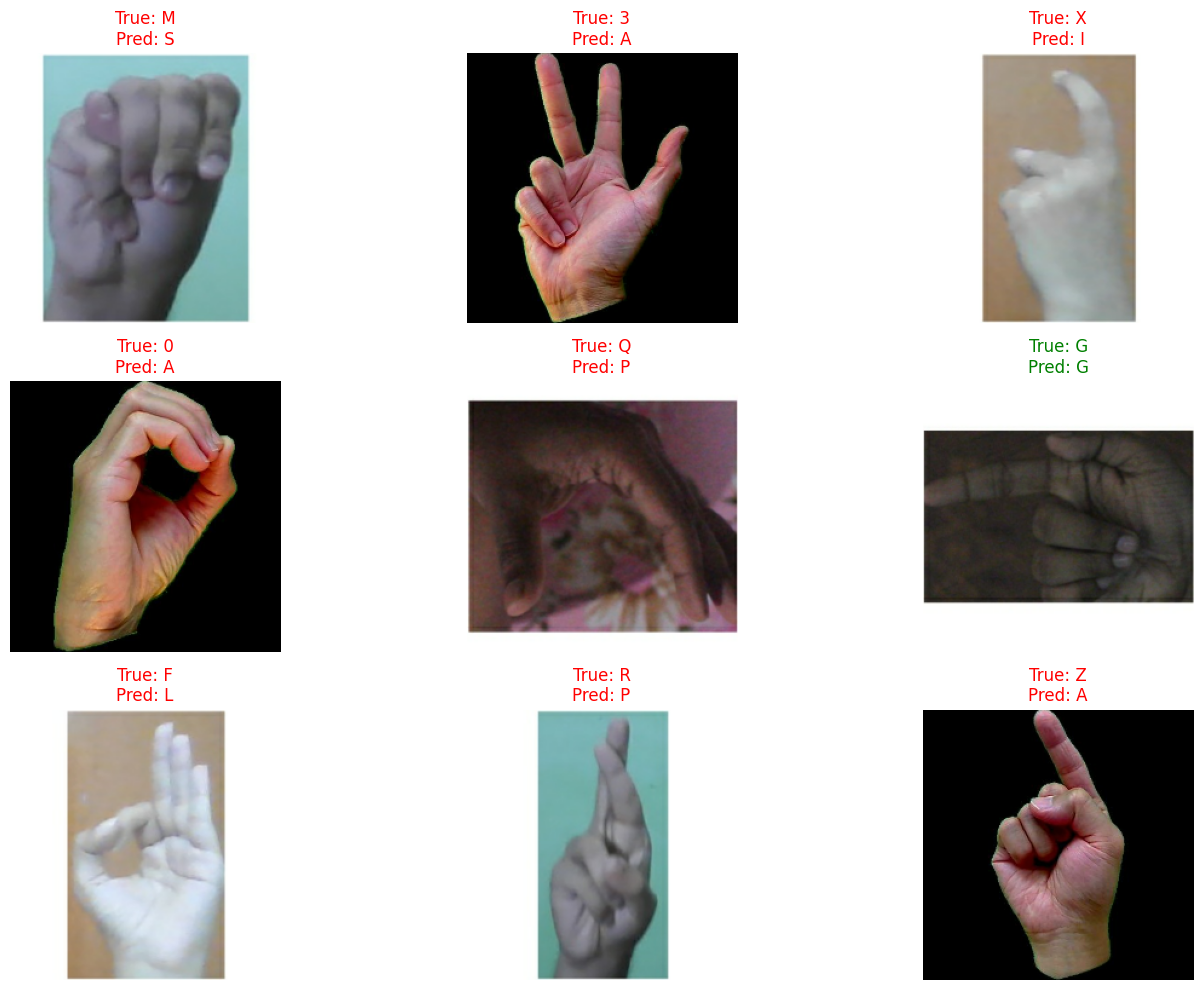

Output:1


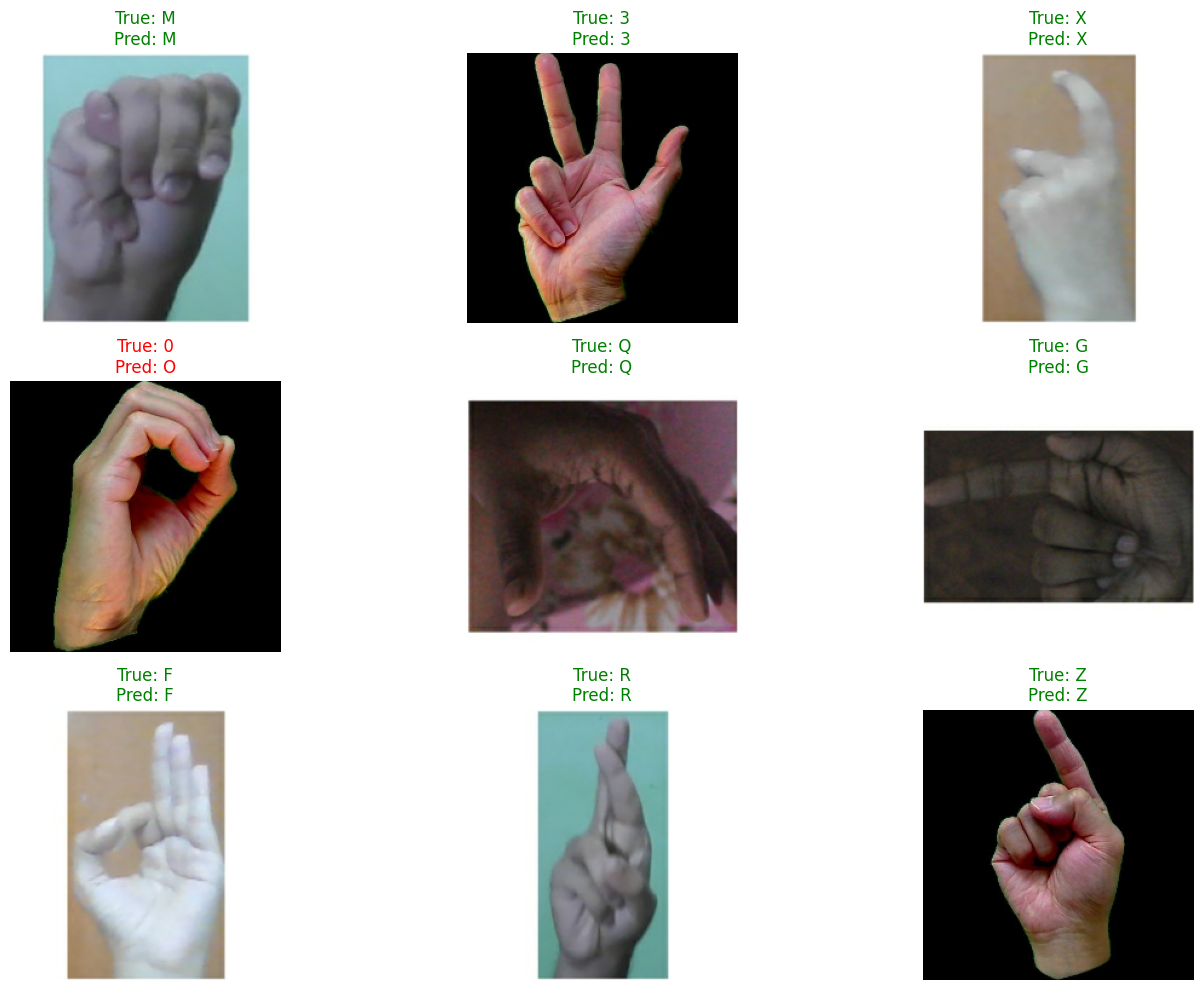

Output:2


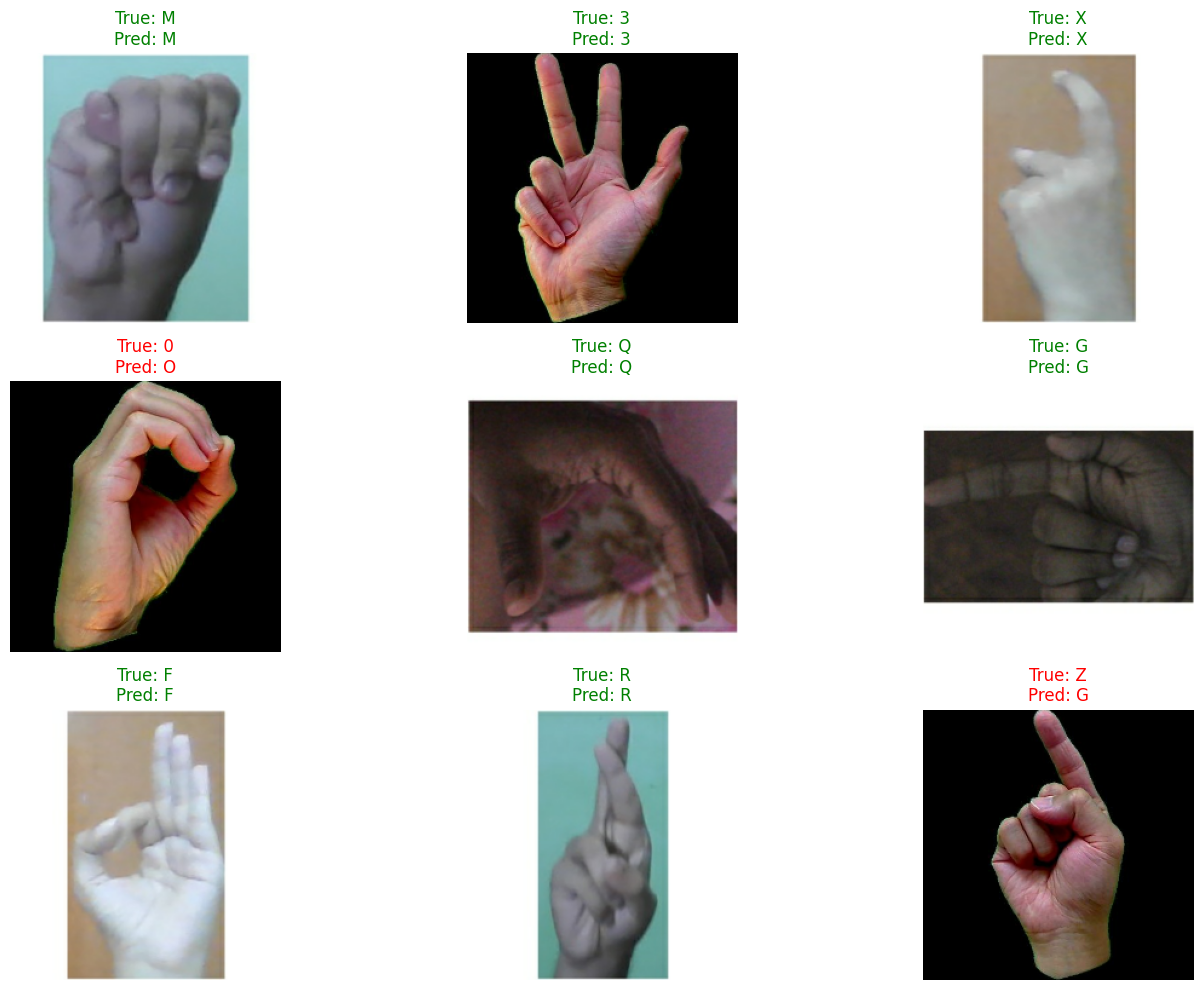

In [25]:
### SHOWS INPUTS, PREDICTIONS AND THE RESPONSE ###

true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(15, 10))
  for i in range(min(len(images), 9)):
      plt.subplot(3, 3, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"True: {true_class_name.upper()}\nPred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [26]:
### EVALUATES EACH EARLY EXIT ###

y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
y_trues_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  preds = LoadedModel.predict(x_batch, verbose=0)
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_trues_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==10: #change depending on how many points in matrix you want
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_trues_list)



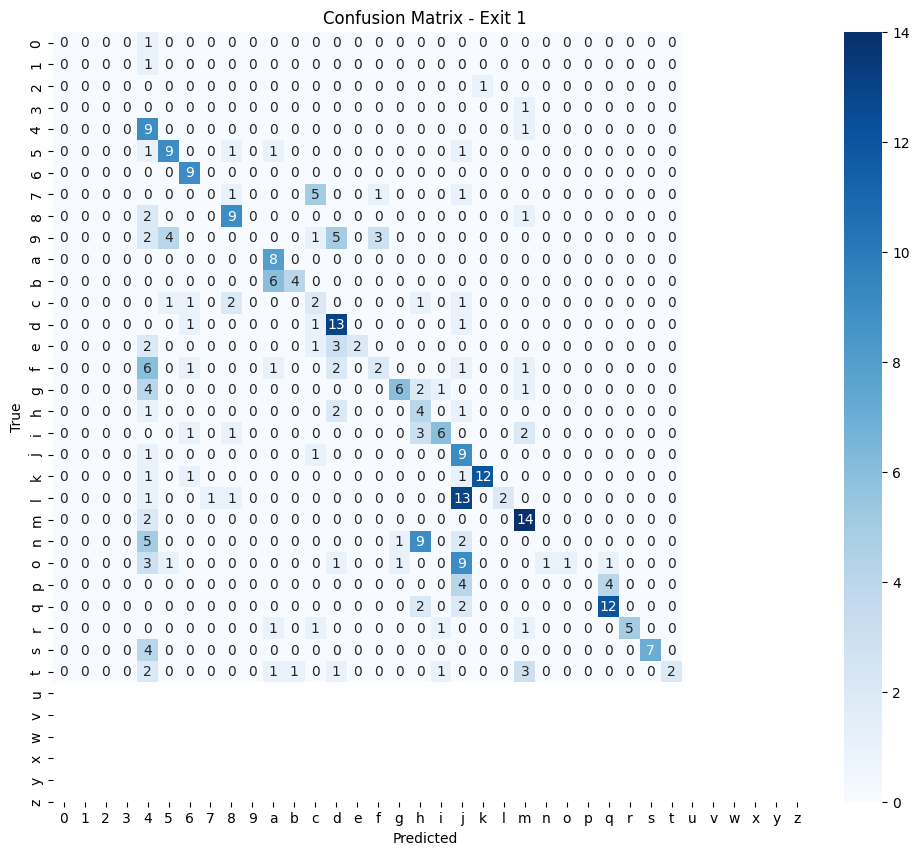

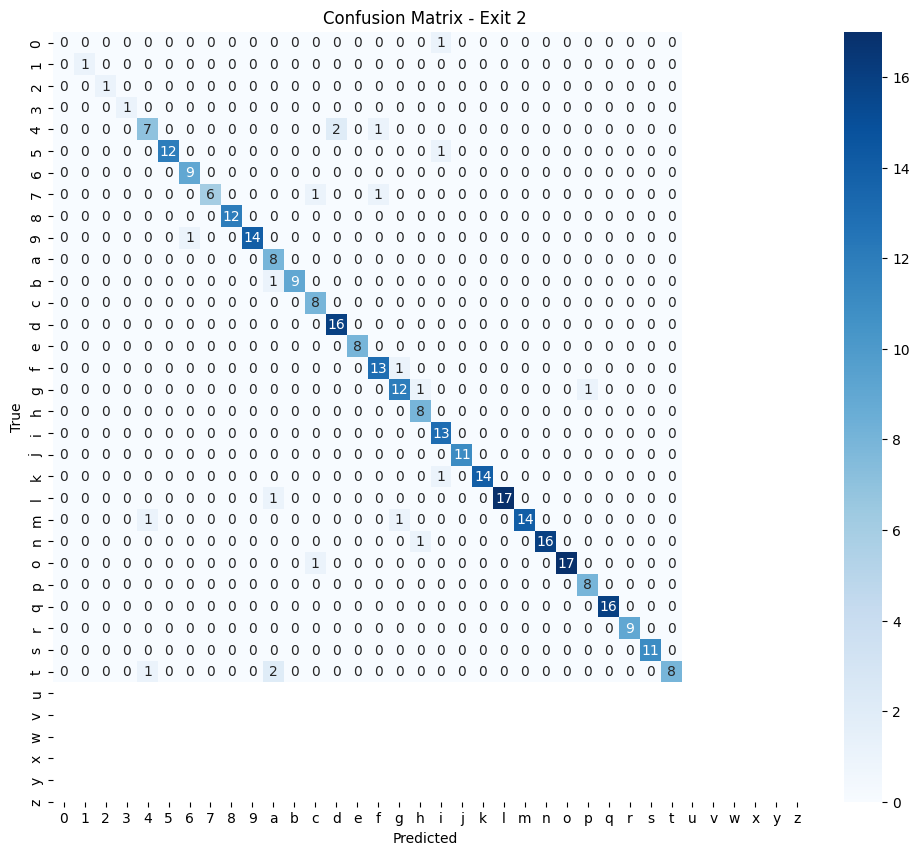

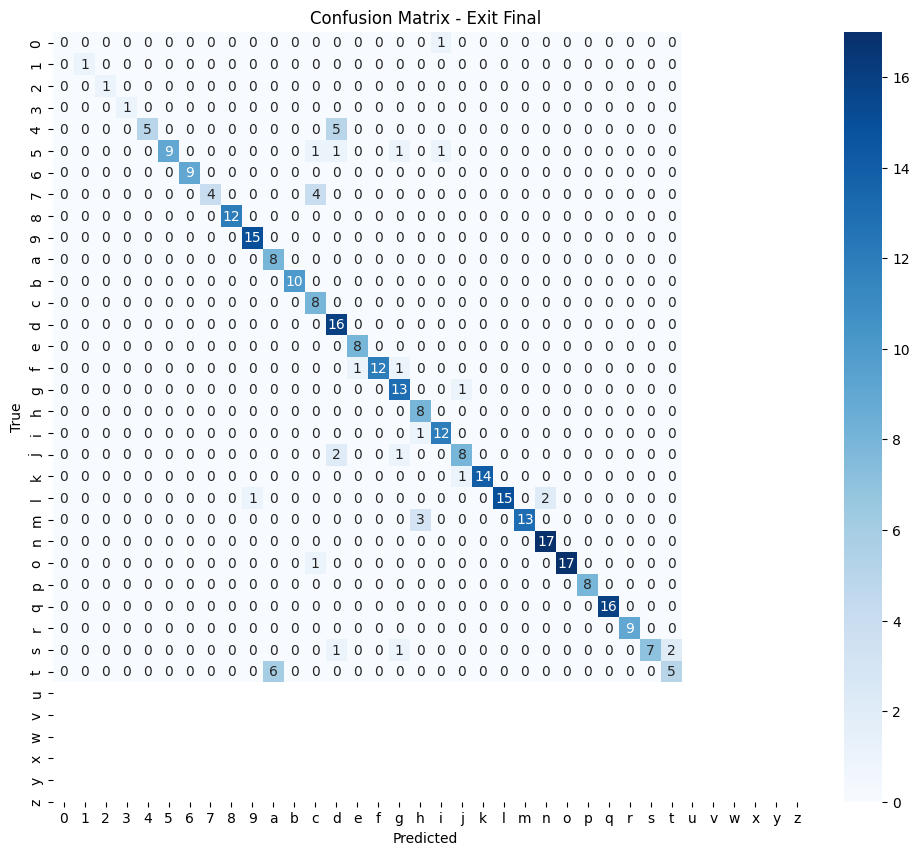

In [28]:
### SHOWS THE CONFUSION MATRIX FOR THE EXITS ###
exits = ["Exit 1", "Exit 2", "Exit Final"]
i = 0
for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title(f"Confusion Matrix - {exits[i]}")
  i +=1
  plt.show()